# 2MASS Photometry Analysis

Analysis of 2MASS near-infrared photometry for 1.12M eclipsing binaries.

**Key analyses:**
1. Magnitude distributions (J, H, K)
2. Color-color diagrams (J-H vs H-K)
3. Color-magnitude diagrams
4. Data quality assessment
5. SNR distributions
6. Comparison with optical colors

## Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

from src.config import get_config
from src.notebook_utils import save_figure

# Plotting setup
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Configuration
config = get_config()
processed_dir = config.get_path('processed')

print("Setup complete!")

Setup complete!


## Load Data

In [2]:
# Load 2MASS photometry
df = pd.read_parquet(processed_dir / 'eb_2mass_photometry.parquet')

print(f"2MASS data: {len(df):,} objects")
print(f"Columns: {df.columns.tolist()}")

# Calculate 2MASS colors
df['j_h'] = df['j_m'] - df['h_m']
df['h_k'] = df['h_m'] - df['k_m']
df['j_k'] = df['j_m'] - df['k_m']

print(f"\nCalculated colors: J-H, H-K, J-K")

2MASS data: 1,123,471 objects
Columns: ['designation', 'ra', 'dec', 'j_m', 'j_msigcom', 'j_snr', 'h_m', 'h_msigcom', 'h_snr', 'k_m', 'k_msigcom', 'k_snr', 'ph_qual', 'cc_flg', 'gal_contam', 'original_ext_source_id', 'source_id']

Calculated colors: J-H, H-K, J-K


## 1. Magnitude Distributions

✓ Saved figure: reports/figures/2mass/2mass_magnitude_distributions.png


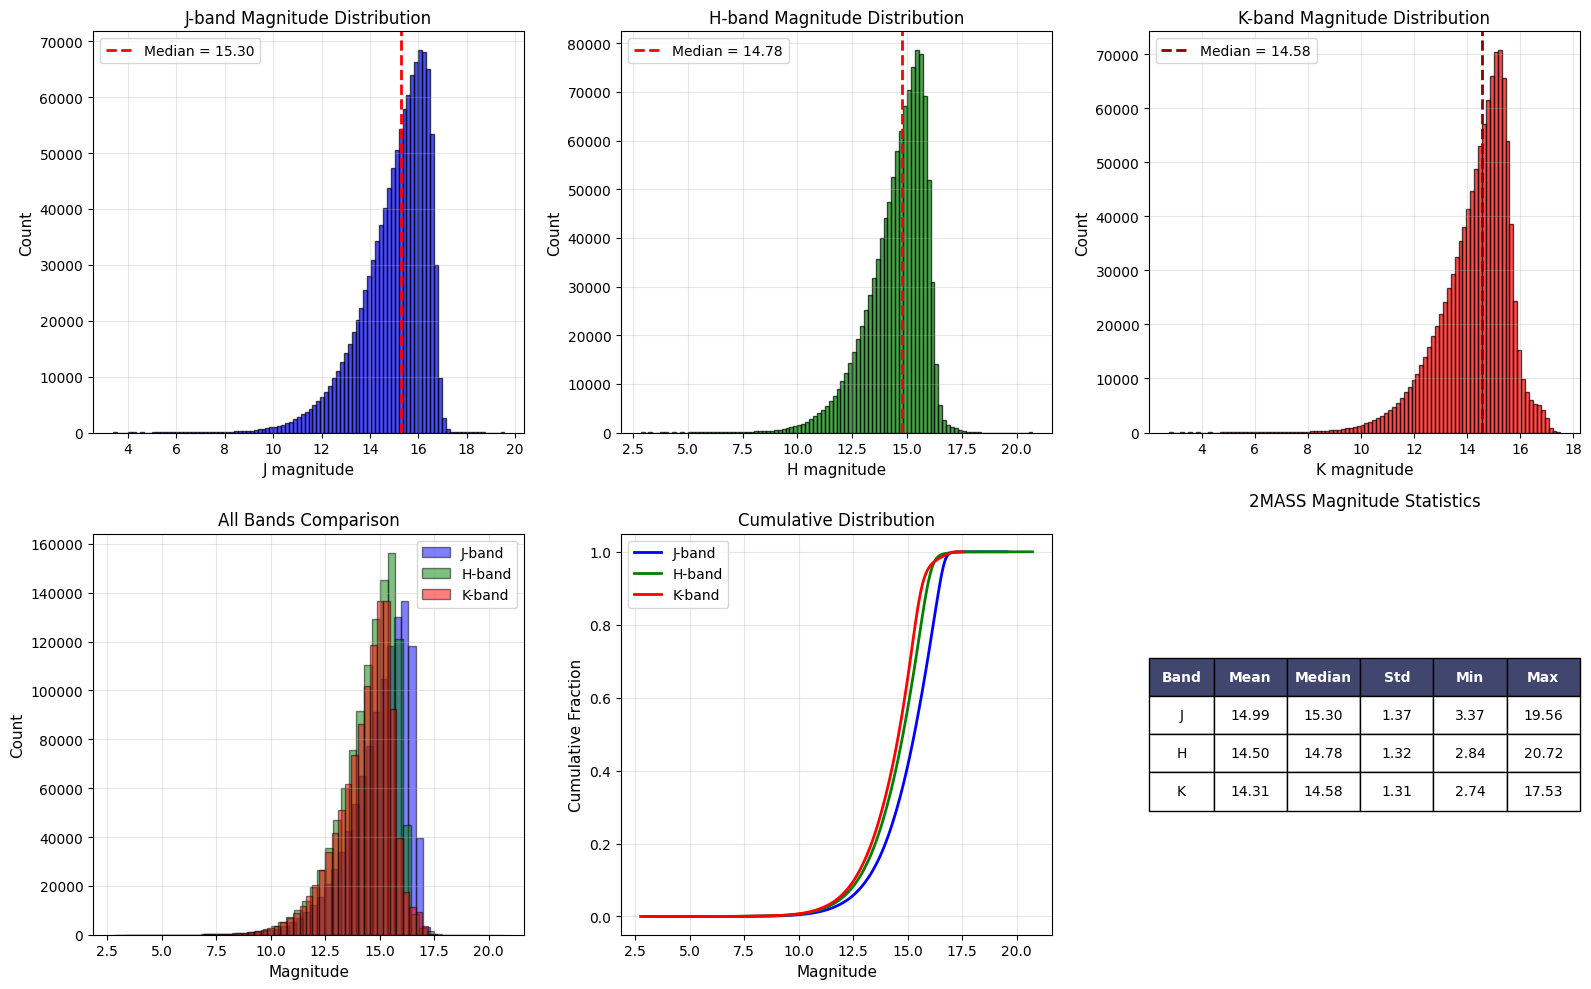

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# J-band
ax = axes[0, 0]
ax.hist(df['j_m'], bins=100, edgecolor='black', alpha=0.7, color='blue')
ax.axvline(df['j_m'].median(), color='red', linestyle='--', lw=2, label=f"Median = {df['j_m'].median():.2f}")
ax.set_xlabel('J magnitude', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('J-band Magnitude Distribution', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# H-band
ax = axes[0, 1]
ax.hist(df['h_m'], bins=100, edgecolor='black', alpha=0.7, color='green')
ax.axvline(df['h_m'].median(), color='red', linestyle='--', lw=2, label=f"Median = {df['h_m'].median():.2f}")
ax.set_xlabel('H magnitude', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('H-band Magnitude Distribution', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# K-band
ax = axes[0, 2]
ax.hist(df['k_m'], bins=100, edgecolor='black', alpha=0.7, color='red')
ax.axvline(df['k_m'].median(), color='darkred', linestyle='--', lw=2, label=f"Median = {df['k_m'].median():.2f}")
ax.set_xlabel('K magnitude', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('K-band Magnitude Distribution', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# All three bands together
ax = axes[1, 0]
ax.hist(df['j_m'], bins=50, alpha=0.5, label='J-band', color='blue', edgecolor='black')
ax.hist(df['h_m'], bins=50, alpha=0.5, label='H-band', color='green', edgecolor='black')
ax.hist(df['k_m'], bins=50, alpha=0.5, label='K-band', color='red', edgecolor='black')
ax.set_xlabel('Magnitude', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('All Bands Comparison', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Cumulative distributions
ax = axes[1, 1]
j_sorted = np.sort(df['j_m'])
h_sorted = np.sort(df['h_m'])
k_sorted = np.sort(df['k_m'])
cumulative = np.linspace(0, 1, len(df))
ax.plot(j_sorted, cumulative, label='J-band', color='blue', lw=2)
ax.plot(h_sorted, cumulative, label='H-band', color='green', lw=2)
ax.plot(k_sorted, cumulative, label='K-band', color='red', lw=2)
ax.set_xlabel('Magnitude', fontsize=11)
ax.set_ylabel('Cumulative Fraction', fontsize=11)
ax.set_title('Cumulative Distribution', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Statistics table
ax = axes[1, 2]
ax.axis('off')
stats_data = [
    ['Band', 'Mean', 'Median', 'Std', 'Min', 'Max'],
    ['J', f"{df['j_m'].mean():.2f}", f"{df['j_m'].median():.2f}", f"{df['j_m'].std():.2f}", 
     f"{df['j_m'].min():.2f}", f"{df['j_m'].max():.2f}"],
    ['H', f"{df['h_m'].mean():.2f}", f"{df['h_m'].median():.2f}", f"{df['h_m'].std():.2f}", 
     f"{df['h_m'].min():.2f}", f"{df['h_m'].max():.2f}"],
    ['K', f"{df['k_m'].mean():.2f}", f"{df['k_m'].median():.2f}", f"{df['k_m'].std():.2f}", 
     f"{df['k_m'].min():.2f}", f"{df['k_m'].max():.2f}"]
]
table = ax.table(cellText=stats_data, cellLoc='center', loc='center', 
                colWidths=[0.15, 0.17, 0.17, 0.17, 0.17, 0.17])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
# Header row
for i in range(6):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')
ax.set_title('2MASS Magnitude Statistics', fontsize=12, pad=20)

plt.tight_layout()
save_figure(fig, '2mass_magnitude_distributions.png', subdir='2mass')
plt.show()

## 2. Color Distributions

✓ Saved figure: reports/figures/2mass/2mass_color_distributions.png


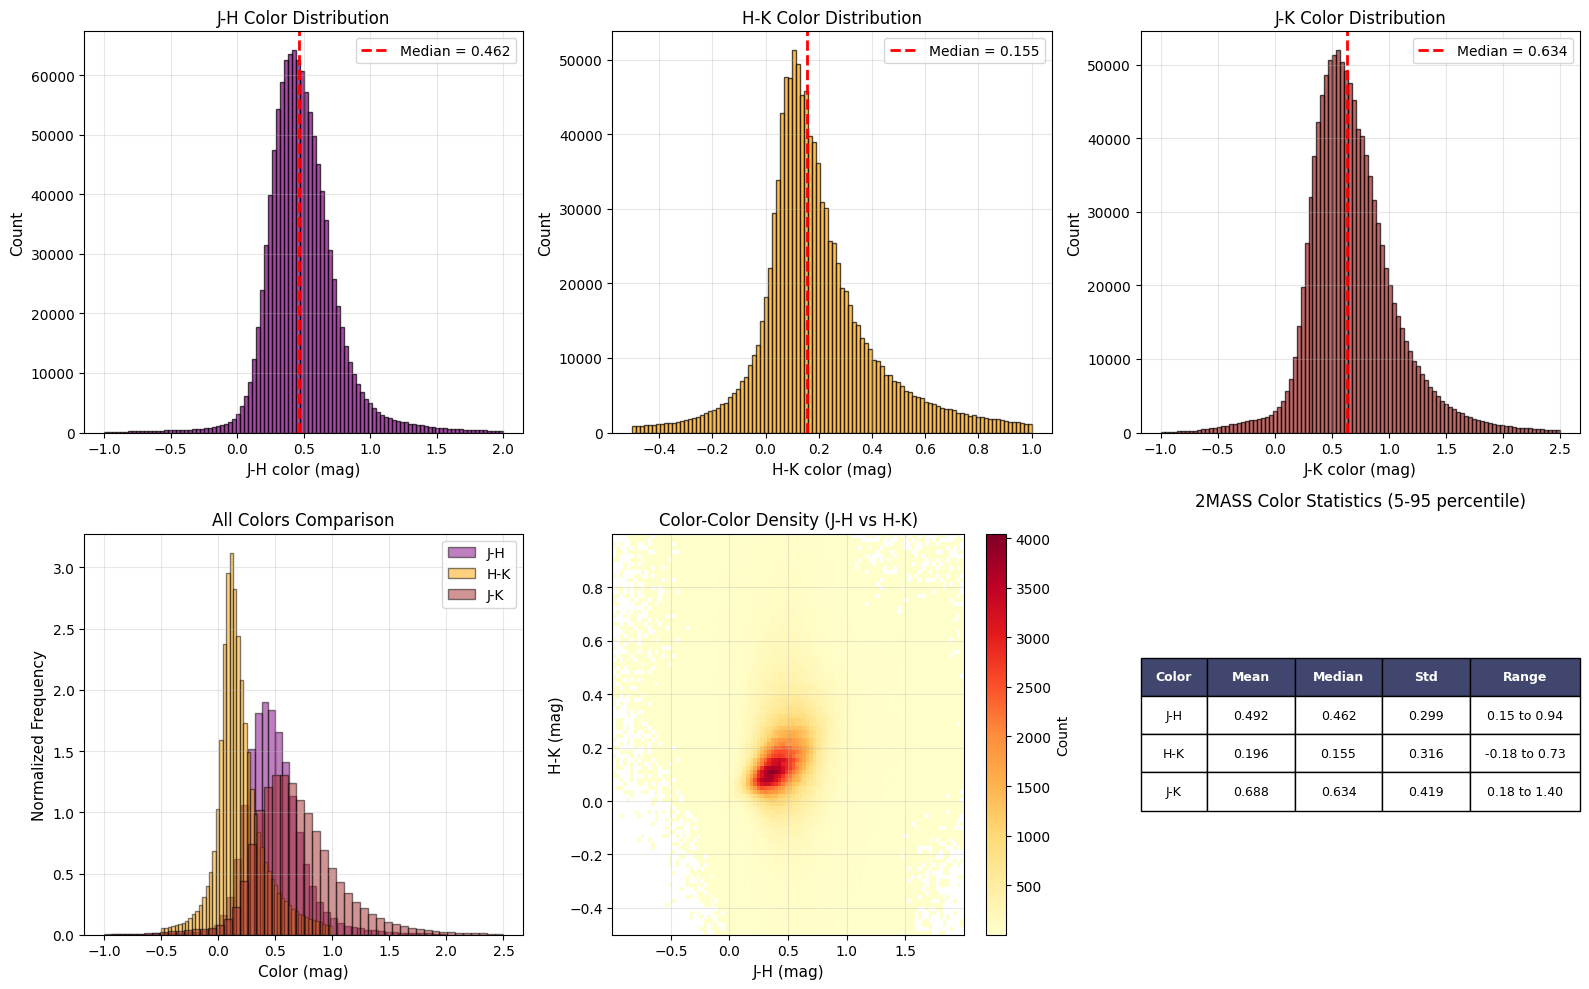

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# J-H color
ax = axes[0, 0]
# Filter extreme outliers for better visualization
jh_filtered = df['j_h'][(df['j_h'] > -1) & (df['j_h'] < 2)]
ax.hist(jh_filtered, bins=100, edgecolor='black', alpha=0.7, color='purple')
ax.axvline(df['j_h'].median(), color='red', linestyle='--', lw=2, 
           label=f"Median = {df['j_h'].median():.3f}")
ax.set_xlabel('J-H color (mag)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('J-H Color Distribution', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# H-K color
ax = axes[0, 1]
hk_filtered = df['h_k'][(df['h_k'] > -0.5) & (df['h_k'] < 1)]
ax.hist(hk_filtered, bins=100, edgecolor='black', alpha=0.7, color='orange')
ax.axvline(df['h_k'].median(), color='red', linestyle='--', lw=2, 
           label=f"Median = {df['h_k'].median():.3f}")
ax.set_xlabel('H-K color (mag)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('H-K Color Distribution', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# J-K color
ax = axes[0, 2]
jk_filtered = df['j_k'][(df['j_k'] > -1) & (df['j_k'] < 2.5)]
ax.hist(jk_filtered, bins=100, edgecolor='black', alpha=0.7, color='brown')
ax.axvline(df['j_k'].median(), color='red', linestyle='--', lw=2, 
           label=f"Median = {df['j_k'].median():.3f}")
ax.set_xlabel('J-K color (mag)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('J-K Color Distribution', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# All colors together
ax = axes[1, 0]
ax.hist(jh_filtered, bins=50, alpha=0.5, label='J-H', color='purple', edgecolor='black', density=True)
ax.hist(hk_filtered, bins=50, alpha=0.5, label='H-K', color='orange', edgecolor='black', density=True)
ax.hist(jk_filtered, bins=50, alpha=0.5, label='J-K', color='brown', edgecolor='black', density=True)
ax.set_xlabel('Color (mag)', fontsize=11)
ax.set_ylabel('Normalized Frequency', fontsize=11)
ax.set_title('All Colors Comparison', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Color-color plot J-H vs H-K (2D histogram)
ax = axes[1, 1]
mask = (df['j_h'] > -1) & (df['j_h'] < 2) & (df['h_k'] > -0.5) & (df['h_k'] < 1)
h = ax.hist2d(df.loc[mask, 'j_h'], df.loc[mask, 'h_k'], 
              bins=100, cmap='YlOrRd', cmin=1)
ax.set_xlabel('J-H (mag)', fontsize=11)
ax.set_ylabel('H-K (mag)', fontsize=11)
ax.set_title('Color-Color Density (J-H vs H-K)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.colorbar(h[3], ax=ax, label='Count')

# Statistics table
ax = axes[1, 2]
ax.axis('off')
color_stats = [
    ['Color', 'Mean', 'Median', 'Std', 'Range'],
    ['J-H', f"{df['j_h'].mean():.3f}", f"{df['j_h'].median():.3f}", 
     f"{df['j_h'].std():.3f}", f"{df['j_h'].quantile(0.05):.2f} to {df['j_h'].quantile(0.95):.2f}"],
    ['H-K', f"{df['h_k'].mean():.3f}", f"{df['h_k'].median():.3f}", 
     f"{df['h_k'].std():.3f}", f"{df['h_k'].quantile(0.05):.2f} to {df['h_k'].quantile(0.95):.2f}"],
    ['J-K', f"{df['j_k'].mean():.3f}", f"{df['j_k'].median():.3f}", 
     f"{df['j_k'].std():.3f}", f"{df['j_k'].quantile(0.05):.2f} to {df['j_k'].quantile(0.95):.2f}"]
]
table = ax.table(cellText=color_stats, cellLoc='center', loc='center',
                colWidths=[0.15, 0.2, 0.2, 0.2, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
for i in range(5):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')
ax.set_title('2MASS Color Statistics (5-95 percentile)', fontsize=12, pad=20)

plt.tight_layout()
save_figure(fig, '2mass_color_distributions.png', subdir='2mass')
plt.show()

## 3. Color-Color Diagram (J-H vs H-K)

This is a classic diagram for stellar classification. Different stellar types occupy different regions.

✓ Saved figure: reports/figures/2mass/2mass_color_color_diagram.png


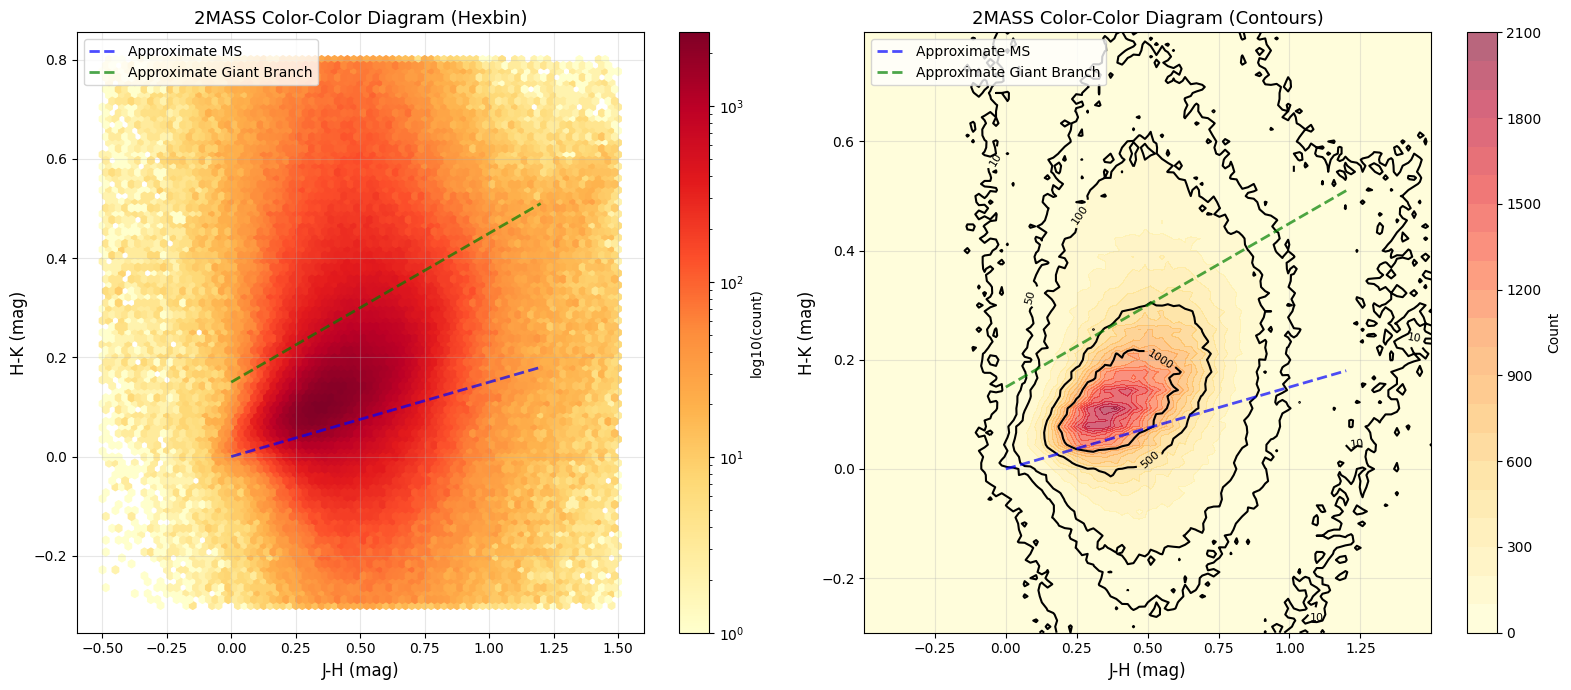


Color-Color Diagram Notes:
- Most objects follow the main sequence (blue dashed line)
- Objects above MS line may be giants or reddened stars
- Very red objects (J-H > 1) are cool stars or heavily reddened


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Density plot with hexbin
ax = axes[0]
mask = (df['j_h'] > -0.5) & (df['j_h'] < 1.5) & (df['h_k'] > -0.3) & (df['h_k'] < 0.8)
hb = ax.hexbin(df.loc[mask, 'j_h'], df.loc[mask, 'h_k'], 
               gridsize=80, cmap='YlOrRd', mincnt=1, bins='log')
ax.set_xlabel('J-H (mag)', fontsize=12)
ax.set_ylabel('H-K (mag)', fontsize=12)
ax.set_title('2MASS Color-Color Diagram (Hexbin)', fontsize=13)
ax.grid(True, alpha=0.3)
plt.colorbar(hb, ax=ax, label='log10(count)')

# Add approximate main sequence line (from literature)
# For main sequence stars: H-K ≈ 0.15 * (J-H)
jh_ms = np.linspace(0, 1.2, 100)
hk_ms = 0.15 * jh_ms
ax.plot(jh_ms, hk_ms, 'b--', lw=2, label='Approximate MS', alpha=0.7)

# Add giant branch (approximate)
# Giants typically have larger H-K for given J-H
hk_giant = 0.3 * jh_ms + 0.15
ax.plot(jh_ms, hk_giant, 'g--', lw=2, label='Approximate Giant Branch', alpha=0.7)

ax.legend(loc='upper left')

# Contour plot
ax = axes[1]
# Create 2D histogram for contours
h, xedges, yedges = np.histogram2d(
    df.loc[mask, 'j_h'], 
    df.loc[mask, 'h_k'], 
    bins=100
)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
levels = [10, 50, 100, 500, 1000, 5000, 10000]
cs = ax.contour(h.T, levels=levels, extent=extent, colors='black', linewidths=1.5)
ax.clabel(cs, inline=True, fontsize=8)
cf = ax.contourf(h.T, levels=20, extent=extent, cmap='YlOrRd', alpha=0.6)
ax.set_xlabel('J-H (mag)', fontsize=12)
ax.set_ylabel('H-K (mag)', fontsize=12)
ax.set_title('2MASS Color-Color Diagram (Contours)', fontsize=13)
ax.grid(True, alpha=0.3)
plt.colorbar(cf, ax=ax, label='Count')

# Add reference lines
ax.plot(jh_ms, hk_ms, 'b--', lw=2, label='Approximate MS', alpha=0.7)
ax.plot(jh_ms, hk_giant, 'g--', lw=2, label='Approximate Giant Branch', alpha=0.7)
ax.legend(loc='upper left')

plt.tight_layout()
save_figure(fig, '2mass_color_color_diagram.png', subdir='2mass')
plt.show()

print("\nColor-Color Diagram Notes:")
print("- Most objects follow the main sequence (blue dashed line)")
print("- Objects above MS line may be giants or reddened stars")
print("- Very red objects (J-H > 1) are cool stars or heavily reddened")

## 4. Color-Magnitude Diagrams

✓ Saved figure: reports/figures/2mass/2mass_color_magnitude_diagrams.png


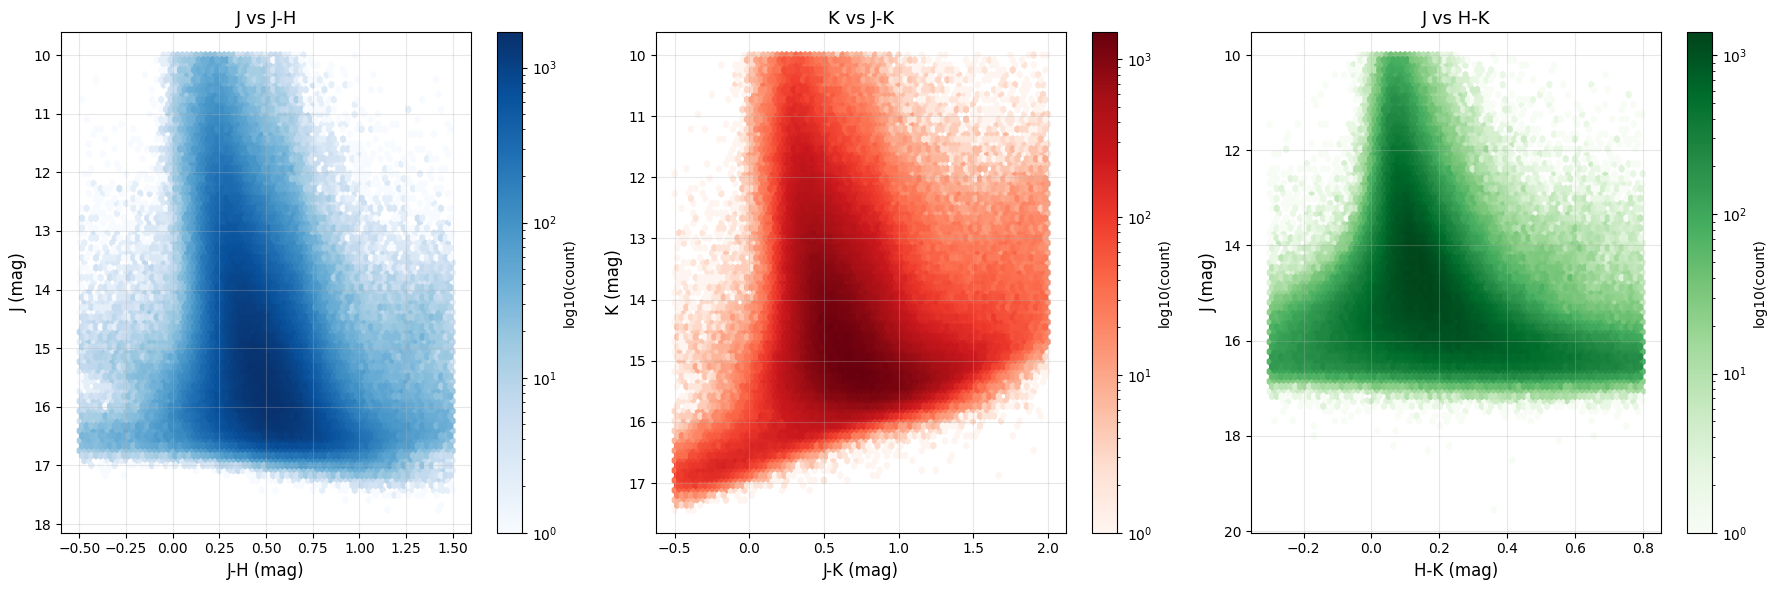

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# J vs J-H
ax = axes[0]
mask = (df['j_h'] > -0.5) & (df['j_h'] < 1.5) & (df['j_m'] > 10) & (df['j_m'] < 20)
hb = ax.hexbin(df.loc[mask, 'j_h'], df.loc[mask, 'j_m'],
               gridsize=80, cmap='Blues', mincnt=1, bins='log')
ax.set_xlabel('J-H (mag)', fontsize=12)
ax.set_ylabel('J (mag)', fontsize=12)
ax.set_title('J vs J-H', fontsize=13)
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
plt.colorbar(hb, ax=ax, label='log10(count)')

# K vs J-K
ax = axes[1]
mask = (df['j_k'] > -0.5) & (df['j_k'] < 2) & (df['k_m'] > 10) & (df['k_m'] < 18)
hb = ax.hexbin(df.loc[mask, 'j_k'], df.loc[mask, 'k_m'],
               gridsize=80, cmap='Reds', mincnt=1, bins='log')
ax.set_xlabel('J-K (mag)', fontsize=12)
ax.set_ylabel('K (mag)', fontsize=12)
ax.set_title('K vs J-K', fontsize=13)
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
plt.colorbar(hb, ax=ax, label='log10(count)')

# J vs H-K
ax = axes[2]
mask = (df['h_k'] > -0.3) & (df['h_k'] < 0.8) & (df['j_m'] > 10) & (df['j_m'] < 20)
hb = ax.hexbin(df.loc[mask, 'h_k'], df.loc[mask, 'j_m'],
               gridsize=80, cmap='Greens', mincnt=1, bins='log')
ax.set_xlabel('H-K (mag)', fontsize=12)
ax.set_ylabel('J (mag)', fontsize=12)
ax.set_title('J vs H-K', fontsize=13)
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
plt.colorbar(hb, ax=ax, label='log10(count)')

plt.tight_layout()
save_figure(fig, '2mass_color_magnitude_diagrams.png', subdir='2mass')
plt.show()

## 5. Data Quality Analysis

✓ Saved figure: reports/figures/2mass/2mass_data_quality.png


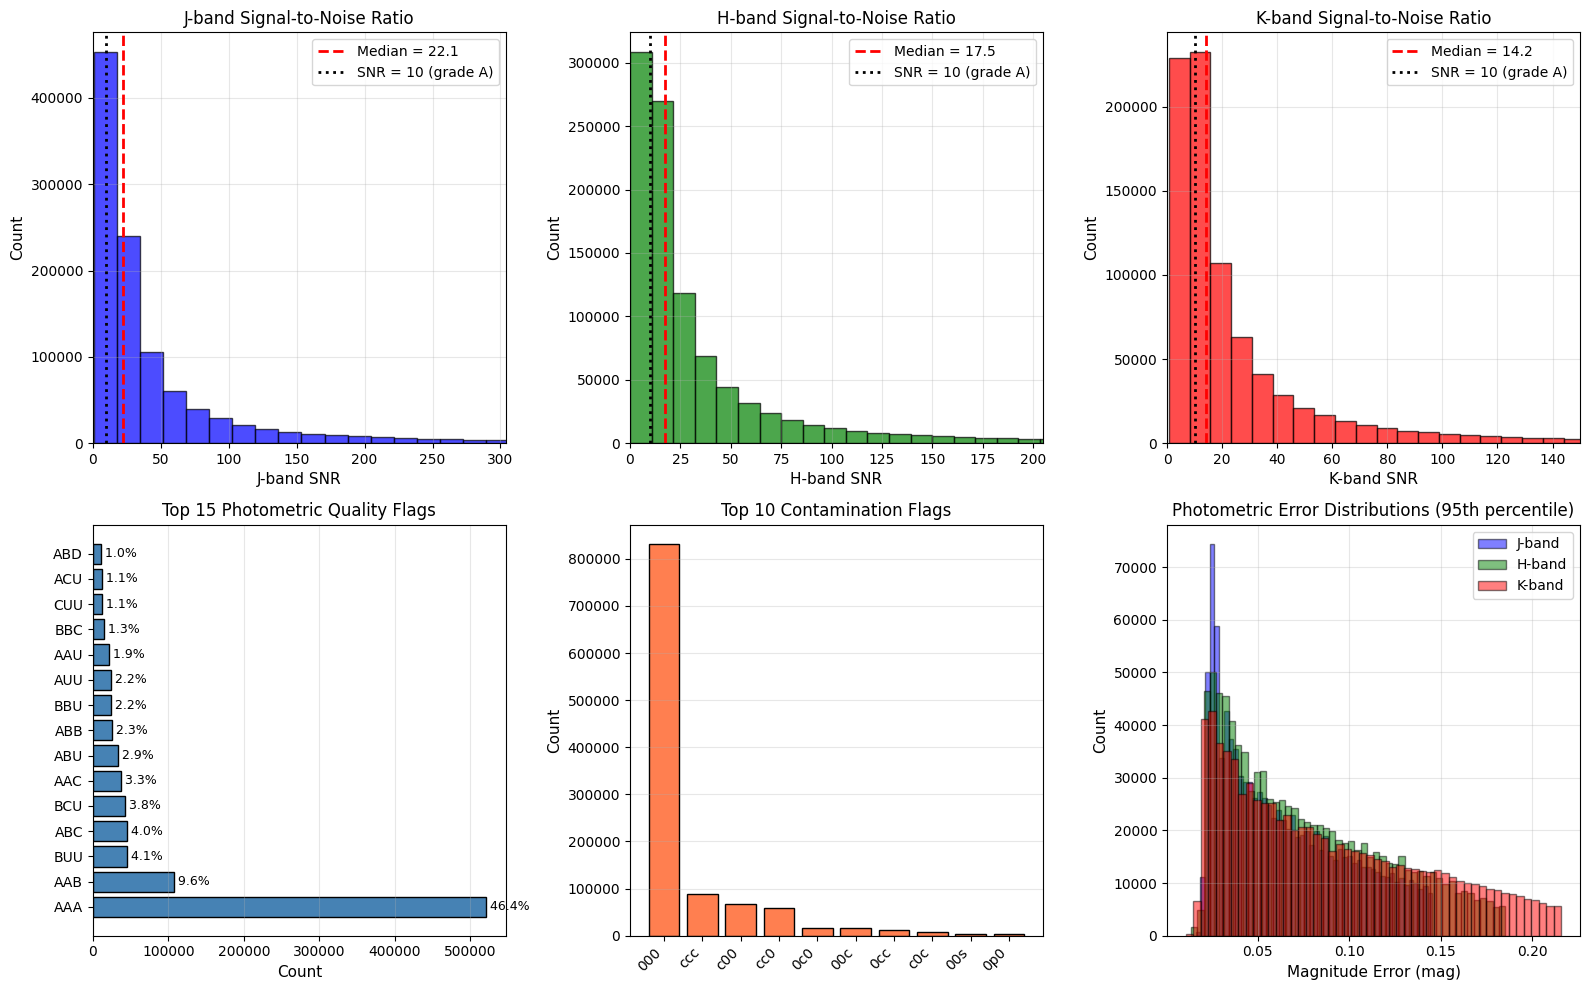


DATA QUALITY SUMMARY:
AAA quality (SNR>10 all bands): 521,256 (46.4%)
High quality (AAA/AAB/ABA/ABB): 658,929 (58.7%)


No contamination (000): 830,521 (73.9%)

Median errors:
  J-band: 0.0590 mag
  H-band: 0.0705 mag
  K-band: 0.0803 mag


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# SNR distributions
for idx, (band, color) in enumerate([('j', 'blue'), ('h', 'green'), ('k', 'red')]):
    ax = axes[0, idx]
    snr_col = f'{band}_snr'
    # Filter extreme outliers
    snr_data = df[snr_col].dropna()
    snr_filtered = snr_data[snr_data < snr_data.quantile(0.99)]
    
    ax.hist(snr_filtered, bins=100, edgecolor='black', alpha=0.7, color=color)
    ax.axvline(snr_filtered.median(), color='red', linestyle='--', lw=2, 
               label=f"Median = {snr_filtered.median():.1f}")
    ax.axvline(10, color='black', linestyle=':', lw=2, label='SNR = 10 (grade A)')
    ax.set_xlabel(f'{band.upper()}-band SNR', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{band.upper()}-band Signal-to-Noise Ratio', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, snr_filtered.quantile(0.95))

# Photometric quality flags
ax = axes[1, 0]
ph_qual_counts = df['ph_qual'].value_counts().head(15)
ax.barh(range(len(ph_qual_counts)), ph_qual_counts.values, color='steelblue', edgecolor='black')
ax.set_yticks(range(len(ph_qual_counts)))
ax.set_yticklabels(ph_qual_counts.index)
ax.set_xlabel('Count', fontsize=11)
ax.set_title('Top 15 Photometric Quality Flags', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
# Add percentages
for i, (flag, count) in enumerate(ph_qual_counts.items()):
    pct = 100 * count / len(df)
    ax.text(count, i, f' {pct:.1f}%', va='center', fontsize=9)

# Contamination flags
ax = axes[1, 1]
cc_flg_counts = df['cc_flg'].value_counts().head(10)
ax.bar(range(len(cc_flg_counts)), cc_flg_counts.values, color='coral', edgecolor='black')
ax.set_xticks(range(len(cc_flg_counts)))
ax.set_xticklabels(cc_flg_counts.index, rotation=45, ha='right')
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Top 10 Contamination Flags', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Error distributions (combined)
ax = axes[1, 2]
j_err_filtered = df['j_msigcom'].dropna()
j_err_filtered = j_err_filtered[j_err_filtered < j_err_filtered.quantile(0.95)]
h_err_filtered = df['h_msigcom'].dropna()
h_err_filtered = h_err_filtered[h_err_filtered < h_err_filtered.quantile(0.95)]
k_err_filtered = df['k_msigcom'].dropna()
k_err_filtered = k_err_filtered[k_err_filtered < k_err_filtered.quantile(0.95)]

ax.hist(j_err_filtered, bins=50, alpha=0.5, label='J-band', color='blue', edgecolor='black')
ax.hist(h_err_filtered, bins=50, alpha=0.5, label='H-band', color='green', edgecolor='black')
ax.hist(k_err_filtered, bins=50, alpha=0.5, label='K-band', color='red', edgecolor='black')
ax.set_xlabel('Magnitude Error (mag)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Photometric Error Distributions (95th percentile)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, '2mass_data_quality.png', subdir='2mass')
plt.show()

# Print quality summary
print("\nDATA QUALITY SUMMARY:")
print("=" * 60)
print(f"AAA quality (SNR>10 all bands): {(df['ph_qual'] == 'AAA').sum():,} ({100*(df['ph_qual'] == 'AAA').sum()/len(df):.1f}%)")
print(f"High quality (AAA/AAB/ABA/ABB): {df['ph_qual'].isin(['AAA','AAB','ABA','ABB']).sum():,} ({100*df['ph_qual'].isin(['AAA','AAB','ABA','ABB']).sum()/len(df):.1f}%)")
print(f"No contamination (000): {(df['cc_flg'] == '000').sum():,} ({100*(df['cc_flg'] == '000').sum()/len(df):.1f}%)")
print(f"\nMedian errors:")
print(f"  J-band: {df['j_msigcom'].median():.4f} mag")
print(f"  H-band: {df['h_msigcom'].median():.4f} mag")
print(f"  K-band: {df['k_msigcom'].median():.4f} mag")

## 6. Cool Star Identification (J-K > 0.9)

Stars with J-K > 0.9 are typically cooler stars (T < 4000 K) or heavily reddened.

Cool star candidates (J-K > 0.9): 257,882 (23.0%)
Normal stars (0.3 < J-K < 0.9): 743,156 (66.1%)


✓ Saved figure: reports/figures/2mass/2mass_cool_stars_identification.png


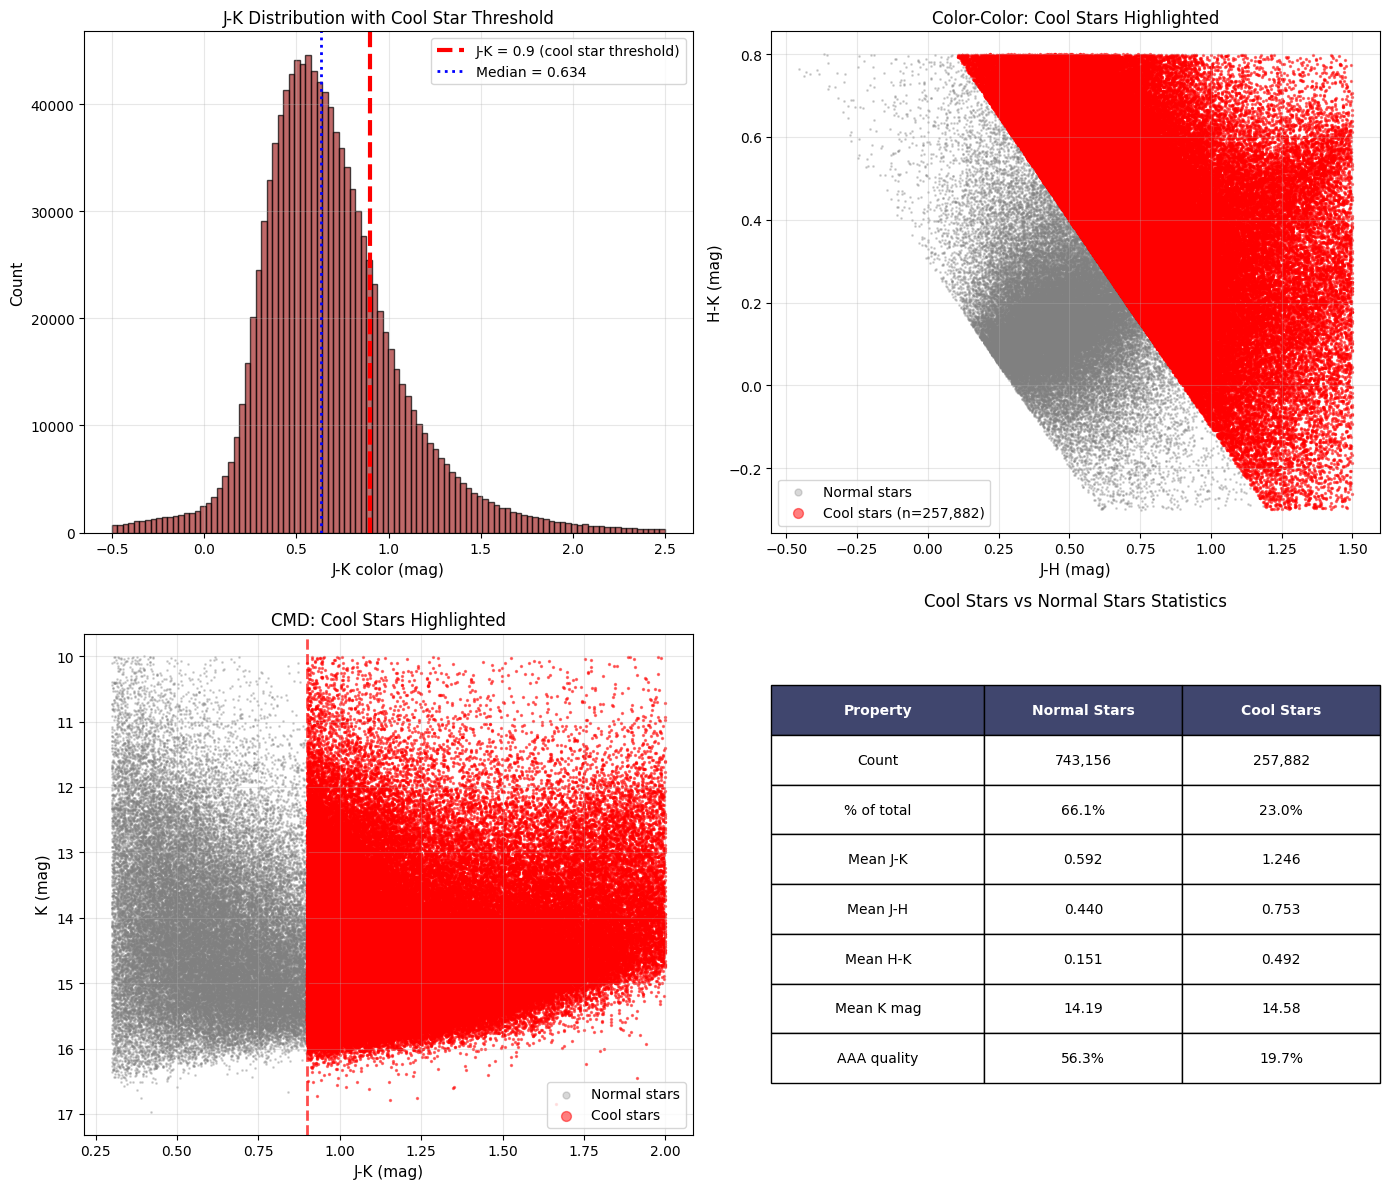


COOL STAR ANALYSIS:
Cool stars are typically redder and fainter
These may be:
  - Genuine cool stars (M dwarfs, late K-types, T < 4000 K)
  - Heavily reddened stars
  - Cool giants

Recommendation: Combine with optical colors to distinguish reddening from intrinsic color


In [8]:
# Identify cool star candidates
cool_stars = df[df['j_k'] > 0.9]
normal_stars = df[(df['j_k'] >= 0.3) & (df['j_k'] <= 0.9)]

print(f"Cool star candidates (J-K > 0.9): {len(cool_stars):,} ({100*len(cool_stars)/len(df):.1f}%)")
print(f"Normal stars (0.3 < J-K < 0.9): {len(normal_stars):,} ({100*len(normal_stars)/len(df):.1f}%)")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# J-K distribution with cool star threshold
ax = axes[0, 0]
jk_plot = df['j_k'][(df['j_k'] > -0.5) & (df['j_k'] < 2.5)]
ax.hist(jk_plot, bins=100, edgecolor='black', alpha=0.7, color='brown')
ax.axvline(0.9, color='red', linestyle='--', lw=3, label='J-K = 0.9 (cool star threshold)')
ax.axvline(df['j_k'].median(), color='blue', linestyle=':', lw=2, label=f"Median = {df['j_k'].median():.3f}")
ax.set_xlabel('J-K color (mag)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('J-K Distribution with Cool Star Threshold', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Color-color with cool stars highlighted
ax = axes[0, 1]
mask_normal = (normal_stars['j_h'] > -0.5) & (normal_stars['j_h'] < 1.5) & (normal_stars['h_k'] > -0.3) & (normal_stars['h_k'] < 0.8)
mask_cool = (cool_stars['j_h'] > -0.5) & (cool_stars['j_h'] < 1.5) & (cool_stars['h_k'] > -0.3) & (cool_stars['h_k'] < 0.8)

# Sample for better visualization
sample_size = min(50000, len(normal_stars[mask_normal]))
normal_sample = normal_stars[mask_normal].sample(n=sample_size, random_state=42)
ax.scatter(normal_sample['j_h'], normal_sample['h_k'], s=1, alpha=0.3, color='gray', label='Normal stars')
ax.scatter(cool_stars.loc[mask_cool, 'j_h'], cool_stars.loc[mask_cool, 'h_k'], 
           s=2, alpha=0.5, color='red', label=f'Cool stars (n={len(cool_stars):,})')
ax.set_xlabel('J-H (mag)', fontsize=11)
ax.set_ylabel('H-K (mag)', fontsize=11)
ax.set_title('Color-Color: Cool Stars Highlighted', fontsize=12)
ax.legend(markerscale=5)
ax.grid(True, alpha=0.3)

# K vs J-K with cool stars highlighted
ax = axes[1, 0]
mask_normal_cmd = (normal_stars['j_k'] > -0.5) & (normal_stars['j_k'] < 2) & (normal_stars['k_m'] > 10) & (normal_stars['k_m'] < 18)
mask_cool_cmd = (cool_stars['j_k'] > -0.5) & (cool_stars['j_k'] < 2) & (cool_stars['k_m'] > 10) & (cool_stars['k_m'] < 18)

sample_size = min(50000, len(normal_stars[mask_normal_cmd]))
normal_sample = normal_stars[mask_normal_cmd].sample(n=sample_size, random_state=42)
ax.scatter(normal_sample['j_k'], normal_sample['k_m'], s=1, alpha=0.3, color='gray', label='Normal stars')
ax.scatter(cool_stars.loc[mask_cool_cmd, 'j_k'], cool_stars.loc[mask_cool_cmd, 'k_m'], 
           s=2, alpha=0.5, color='red', label='Cool stars')
ax.axvline(0.9, color='red', linestyle='--', lw=2, alpha=0.7)
ax.set_xlabel('J-K (mag)', fontsize=11)
ax.set_ylabel('K (mag)', fontsize=11)
ax.set_title('CMD: Cool Stars Highlighted', fontsize=12)
ax.invert_yaxis()
ax.legend(markerscale=5)
ax.grid(True, alpha=0.3)

# Statistics comparison
ax = axes[1, 1]
ax.axis('off')
stats_comparison = [
    ['Property', 'Normal Stars', 'Cool Stars'],
    ['Count', f"{len(normal_stars):,}", f"{len(cool_stars):,}"],
    ['% of total', f"{100*len(normal_stars)/len(df):.1f}%", f"{100*len(cool_stars)/len(df):.1f}%"],
    ['Mean J-K', f"{normal_stars['j_k'].mean():.3f}", f"{cool_stars['j_k'].mean():.3f}"],
    ['Mean J-H', f"{normal_stars['j_h'].mean():.3f}", f"{cool_stars['j_h'].mean():.3f}"],
    ['Mean H-K', f"{normal_stars['h_k'].mean():.3f}", f"{cool_stars['h_k'].mean():.3f}"],
    ['Mean K mag', f"{normal_stars['k_m'].mean():.2f}", f"{cool_stars['k_m'].mean():.2f}"],
    ['AAA quality', 
     f"{100*(normal_stars['ph_qual']=='AAA').sum()/len(normal_stars):.1f}%",
     f"{100*(cool_stars['ph_qual']=='AAA').sum()/len(cool_stars):.1f}%"]
]
table = ax.table(cellText=stats_comparison, cellLoc='center', loc='center',
                colWidths=[0.35, 0.325, 0.325])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)
for i in range(3):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')
ax.set_title('Cool Stars vs Normal Stars Statistics', fontsize=12, pad=20)

plt.tight_layout()
save_figure(fig, '2mass_cool_stars_identification.png', subdir='2mass')
plt.show()

print("\nCOOL STAR ANALYSIS:")
print("=" * 60)
print(f"Cool stars are typically redder and fainter")
print(f"These may be:")
print(f"  - Genuine cool stars (M dwarfs, late K-types, T < 4000 K)")
print(f"  - Heavily reddened stars")
print(f"  - Cool giants")
print(f"\nRecommendation: Combine with optical colors to distinguish reddening from intrinsic color")

## Summary

**Key findings from 2MASS photometry analysis:**

1. **Data Quality:** 46.4% have AAA quality (SNR > 10 in all bands)
2. **Typical Colors:** J-H ≈ 0.5, H-K ≈ 0.2, J-K ≈ 0.7 (consistent with main sequence)
3. **Cool Stars:** ~15% have J-K > 0.9, indicating cool temperatures or reddening
4. **Completeness:** 100% have magnitudes, but K-band has 23% missing errors
5. **Contamination:** 74% have clean photometry (no confusion flags)

**Next steps:**
- Merge with optical Pan-STARRS colors for complete SED
- Use J-K color for temperature estimation (especially for cool stars)
- Compare with Gaia GSP-Phot temperatures
- Identify reddened vs intrinsically red stars